# Combined LSTM Model with Stock Indicators

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted 4178 CSV files
🔍 Reading CSVs and calculating indicators...
✅ Combined dataset shape: (1815824, 13)
📈 Unique companies: 4176
Scaler saved to /content/drive/MyDrive/stock_scaler.npy
Total sequences: 1758193 | Features per step: 10


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

43955/43955 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.2928e-05 - mae: 0.0031
Epoch 1: val_loss improved from inf to 0.00001, saving model to /content/drive/MyDrive/stock_model_lstm.h5


43955/43955 ━━━━━━━━━━━━━━━━━━━━ 635s 14ms/step - loss: 7.2927e-05 - mae: 0.0031 - val_loss: 8.2342e-06 - val_mae: 0.0012
10989/10989 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - loss: 8.3421e-06 - mae: 0.0012
Test MAE (normalized): 0.0012270861770957708
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


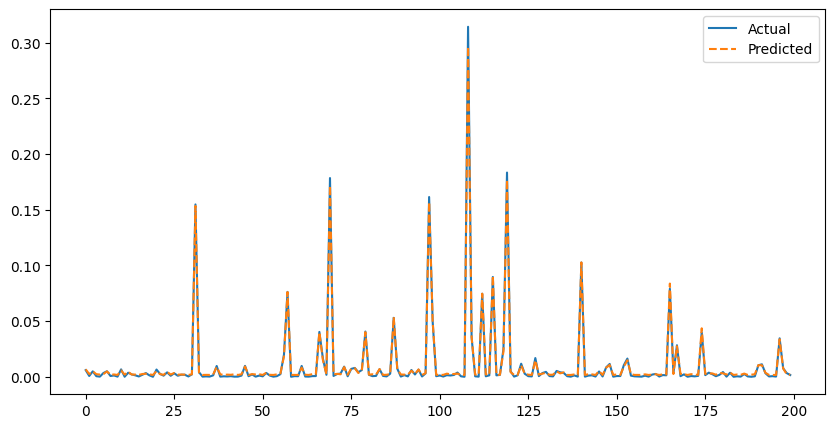

In [1]:
# ============================================
# Multi-Stock LSTM with Technical Indicators
# ============================================

# Install required libraries
!pip install ta --quiet

# ============================================
# Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Unzip your stock data
# ============================================
import zipfile
import os
os.listdir('/content')

zip_path = '/content/data.zip'  # <- Change path
extract_path = '/content/data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted {len(os.listdir(extract_path))} CSV files")

# ============================================
# Imports
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
import ta
import matplotlib.pyplot as plt

# ============================================
# Settings
# ============================================
SEQ_LEN = 15
EPOCHS = 1
BATCH_SIZE = 32
DATA_DIR = extract_path
MODEL_SAVE_PATH = '/content/drive/MyDrive/stock_model_lstm.h5'
SCALER_SAVE_PATH = '/content/drive/MyDrive/stock_scaler.npy'

# ============================================
# Sequence creation helper
# ============================================
def create_sequences(data, target_col, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, target_col])
    return np.array(X), np.array(y)

# ============================================
# Load and combine all stocks with indicators
# ============================================
all_data = []
print("🔍 Reading CSVs and calculating indicators...")

for filename in os.listdir(DATA_DIR):
    if not filename.endswith(".csv"):
        continue
    symbol = filename.split(".")[0]
    filepath = os.path.join(DATA_DIR, filename)

    try:
        df = pd.read_csv(filepath)
        required_cols = ['date','open','high','low','close','volume']
        if not set(required_cols).issubset(df.columns):
            continue
        df = df.dropna(subset=required_cols)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

        # Add indicators
        df['rsi'] = ta.momentum.RSIIndicator(df['close']).rsi()
        df['ema_10'] = ta.trend.EMAIndicator(df['close'], window=10).ema_indicator()
        df['ema_20'] = ta.trend.EMAIndicator(df['close'], window=20).ema_indicator()
        df['macd'] = ta.trend.MACD(df['close']).macd()
        df['stoch'] = ta.momentum.StochasticOscillator(df['high'], df['low'], df['close']).stoch()

        # Handle infinities and NaNs
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df = df.ffill().bfill()

        df['symbol'] = symbol
        all_data.append(df)
    except Exception as e:
        print(f"Skipping {filename}: {e}")

# Combine all
df_all = pd.concat(all_data, ignore_index=True)
print(f"✅ Combined dataset shape: {df_all.shape}")
print(f"📈 Unique companies: {df_all['symbol'].nunique()}")

# ============================================
# Features and target
# ============================================
features = ['open','high','low','close','volume','rsi','ema_10','ema_20','macd','stoch']
target = 'close'

# Ensure numeric
for col in features:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all = df_all.dropna(subset=features)

# Scale
scaler = MinMaxScaler()
df_all[features] = scaler.fit_transform(df_all[features])

# Save scaler
np.save(SCALER_SAVE_PATH, scaler.scale_)
print(f"Scaler saved to {SCALER_SAVE_PATH}")

# ============================================
# Create sequences
# ============================================
X_total, y_total = [], []

for symbol, df_sym in df_all.groupby('symbol'):
    data = df_sym[features].values
    target_idx = features.index(target)
    if len(data) <= SEQ_LEN:
        continue
    X, y = create_sequences(data, target_idx, SEQ_LEN)
    X_total.append(X)
    y_total.append(y)

X_total = np.vstack(X_total)
y_total = np.concatenate(y_total)
print(f"Total sequences: {X_total.shape[0]} | Features per step: {X_total.shape[2]}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_total, y_total, test_size=0.2, shuffle=True, random_state=42
)

# ============================================
# Build LSTM model
# ============================================
def build_lstm(seq_len, n_features):
    inputs = layers.Input(shape=(seq_len, n_features))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.LSTM(32)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)
    return models.Model(inputs, outputs)

model = build_lstm(SEQ_LEN, X_train.shape[2])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================
# Train with checkpoint
# ============================================
checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint],
    verbose=1
)

# ============================================
# Evaluate
# ============================================
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE (normalized): {mae}")

# Predict sample
preds = model.predict(X_test[:200])

plt.figure(figsize=(10,5))
plt.plot(y_test[:200], label='Actual')
plt.plot(preds, label='Predicted', linestyle='--')
plt.legend()
plt.show()


## Combined LSTM and CNN model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted 4178 CSV files
🔍 Reading CSVs and calculating indicators...
✅ Combined dataset shape: (1815824, 13)
📈 Unique companies: 4176
Scaler saved to /content/drive/MyDrive/stock_scaler.npy
Total sequences: 1758193 | Features per step: 10


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 15, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 15, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,497 (181.63 KB)

 Trainable params: 46,497 (181.63 KB)

 Non-trainable params: 0 (0.00 B)

43952/43955 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.7580e-05 - mae: 0.0031
Epoch 1: val_loss improved from inf to 0.00015, saving model to /content/drive/MyDrive/stock_model_lstm.h5


43955/43955 ━━━━━━━━━━━━━━━━━━━━ 797s 18ms/step - loss: 6.7579e-05 - mae: 0.0031 - val_loss: 1.5134e-04 - val_mae: 0.0091
10989/10989 ━━━━━━━━━━━━━━━━━━━━ 64s 6ms/step - loss: 1.5146e-04 - mae: 0.0091
Test MAE (normalized): 0.009117239154875278
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


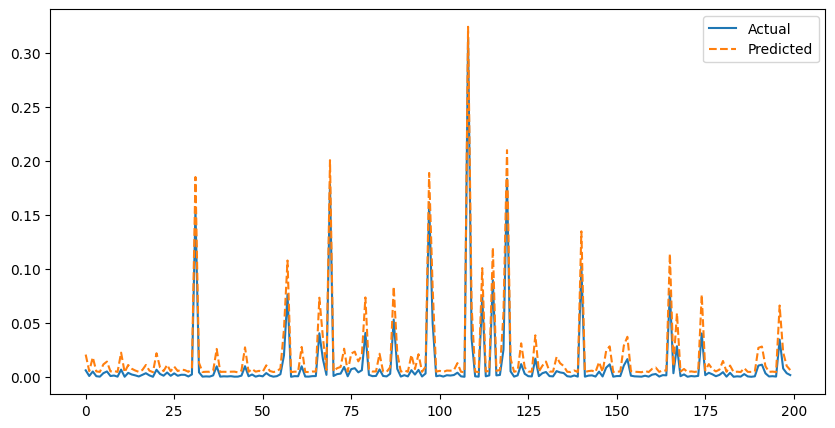

In [2]:
# ============================================
# Multi-Stock LSTM with Technical Indicators
# ============================================

# Install required libraries
!pip install ta --quiet

# ============================================
# Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Unzip your stock data
# ============================================
import zipfile
import os
os.listdir('/content')

zip_path = '/content/data.zip'  # <- Change path
extract_path = '/content/data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted {len(os.listdir(extract_path))} CSV files")

# ============================================
# Imports
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
import ta
import matplotlib.pyplot as plt

# ============================================
# Settings
# ============================================
SEQ_LEN = 15
EPOCHS = 1
BATCH_SIZE = 32
DATA_DIR = extract_path
MODEL_SAVE_PATH = '/content/drive/MyDrive/stock_model_lstm.h5'
SCALER_SAVE_PATH = '/content/drive/MyDrive/stock_scaler.npy'

# ============================================
# Sequence creation helper
# ============================================
def create_sequences(data, target_col, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, target_col])
    return np.array(X), np.array(y)

# ============================================
# Load and combine all stocks with indicators
# ============================================
all_data = []
print("🔍 Reading CSVs and calculating indicators...")

for filename in os.listdir(DATA_DIR):
    if not filename.endswith(".csv"):
        continue
    symbol = filename.split(".")[0]
    filepath = os.path.join(DATA_DIR, filename)

    try:
        df = pd.read_csv(filepath)
        required_cols = ['date','open','high','low','close','volume']
        if not set(required_cols).issubset(df.columns):
            continue
        df = df.dropna(subset=required_cols)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

        # Add indicators
        df['rsi'] = ta.momentum.RSIIndicator(df['close']).rsi()
        df['ema_10'] = ta.trend.EMAIndicator(df['close'], window=10).ema_indicator()
        df['ema_20'] = ta.trend.EMAIndicator(df['close'], window=20).ema_indicator()
        df['macd'] = ta.trend.MACD(df['close']).macd()
        df['stoch'] = ta.momentum.StochasticOscillator(df['high'], df['low'], df['close']).stoch()

        # Handle infinities and NaNs
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df = df.ffill().bfill()

        df['symbol'] = symbol
        all_data.append(df)
    except Exception as e:
        print(f"Skipping {filename}: {e}")

# Combine all
df_all = pd.concat(all_data, ignore_index=True)
print(f"✅ Combined dataset shape: {df_all.shape}")
print(f"📈 Unique companies: {df_all['symbol'].nunique()}")

# ============================================
# Features and target
# ============================================
features = ['open','high','low','close','volume','rsi','ema_10','ema_20','macd','stoch']
target = 'close'

# Ensure numeric
for col in features:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all = df_all.dropna(subset=features)

# Scale
scaler = MinMaxScaler()
df_all[features] = scaler.fit_transform(df_all[features])

# Save scaler
np.save(SCALER_SAVE_PATH, scaler.scale_)
print(f"Scaler saved to {SCALER_SAVE_PATH}")

# ============================================
# Create sequences
# ============================================
X_total, y_total = [], []

for symbol, df_sym in df_all.groupby('symbol'):
    data = df_sym[features].values
    target_idx = features.index(target)
    if len(data) <= SEQ_LEN:
        continue
    X, y = create_sequences(data, target_idx, SEQ_LEN)
    X_total.append(X)
    y_total.append(y)

X_total = np.vstack(X_total)
y_total = np.concatenate(y_total)
print(f"Total sequences: {X_total.shape[0]} | Features per step: {X_total.shape[2]}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_total, y_total, test_size=0.2, shuffle=True, random_state=42
)

# ============================================
# Build LSTM-CNN model
# ============================================
def build_lstm_cnn(seq_len, n_features):
    inputs = layers.Input(shape=(seq_len, n_features))

    # 1D Convolutional layers
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal')(inputs)
    x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='causal')(x)
    x = layers.Dropout(0.2)(x)

    # LSTM layers
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(32)(x)

    # Dense layers
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)

    return models.Model(inputs, outputs)

model = build_lstm_cnn(SEQ_LEN, X_train.shape[2])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


# ============================================
# Train with checkpoint
# ============================================
checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint],
    verbose=1
)

# ============================================
# Evaluate
# ============================================
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE (normalized): {mae}")

# Predict sample
preds = model.predict(X_test[:200])

plt.figure(figsize=(10,5))
plt.plot(y_test[:200], label='Actual')
plt.plot(preds, label='Predicted', linestyle='--')
plt.legend()
plt.show()


## With Transformers

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted 4177 CSV files
🔍 Reading CSVs and calculating indicators...
✅ Combined dataset shape: (1815824, 13)
📈 Unique companies: 4176
Scaler saved to /content/drive/MyDrive/stock_scaler.npy
Total sequences: 1758193 | Features per step: 10


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 15, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 10)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 10)    │         20 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 10)    │     11,018 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 15, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 15, 10)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 15, 64)    │        704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 15, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 15, 10)    │        650 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 15, 10)    │          0 │ dense_1[0][0],    │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 10)    │     11,018 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 15, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 15, 10)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 15, 64)    │        704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 15, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 15, 10)    │        650 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 15, 10)    │          0 │ dense_3[0][0],  

 Total params: 25,593 (99.97 KB)

 Trainable params: 25,593 (99.97 KB)

 Non-trainable params: 0 (0.00 B)

43952/43955 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.6115e-04 - mae: 0.0058
Epoch 1: val_loss improved from inf to 0.00003, saving model to /content/drive/MyDrive/stock_model_lstm.h5


43955/43955 ━━━━━━━━━━━━━━━━━━━━ 678s 15ms/step - loss: 3.6112e-04 - mae: 0.0058 - val_loss: 2.8839e-05 - val_mae: 0.0018
10989/10989 ━━━━━━━━━━━━━━━━━━━━ 54s 5ms/step - loss: 2.7709e-05 - mae: 0.0018
Test MAE (normalized): 0.0017891075694933534
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


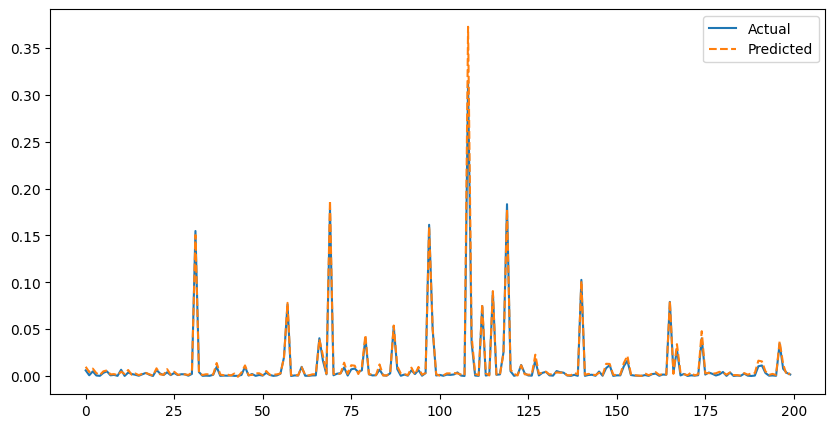

In [3]:
# ============================================
# Multi-Stock LSTM with Technical Indicators
# ============================================

# Install required libraries
!pip install ta --quiet

# ============================================
# Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Unzip your stock data
# ============================================
import zipfile
import os
os.listdir('/content')

zip_path = '/content/data.zip'  # <- Change path
extract_path = '/content/data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted {len(os.listdir(extract_path))} CSV files")

# ============================================
# Imports
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
import ta
import matplotlib.pyplot as plt

# ============================================
# Settings
# ============================================
SEQ_LEN = 15
EPOCHS = 1
BATCH_SIZE = 32
DATA_DIR = extract_path
MODEL_SAVE_PATH = '/content/drive/MyDrive/stock_model_lstm.h5'
SCALER_SAVE_PATH = '/content/drive/MyDrive/stock_scaler.npy'

# ============================================
# Sequence creation helper
# ============================================
def create_sequences(data, target_col, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, target_col])
    return np.array(X), np.array(y)

# ============================================
# Load and combine all stocks with indicators
# ============================================
all_data = []
print("🔍 Reading CSVs and calculating indicators...")

for filename in os.listdir(DATA_DIR):
    if not filename.endswith(".csv"):
        continue
    symbol = filename.split(".")[0]
    filepath = os.path.join(DATA_DIR, filename)

    try:
        df = pd.read_csv(filepath)
        required_cols = ['date','open','high','low','close','volume']
        if not set(required_cols).issubset(df.columns):
            continue
        df = df.dropna(subset=required_cols)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

        # Add indicators
        df['rsi'] = ta.momentum.RSIIndicator(df['close']).rsi()
        df['ema_10'] = ta.trend.EMAIndicator(df['close'], window=10).ema_indicator()
        df['ema_20'] = ta.trend.EMAIndicator(df['close'], window=20).ema_indicator()
        df['macd'] = ta.trend.MACD(df['close']).macd()
        df['stoch'] = ta.momentum.StochasticOscillator(df['high'], df['low'], df['close']).stoch()

        # Handle infinities and NaNs
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df = df.ffill().bfill()

        df['symbol'] = symbol
        all_data.append(df)
    except Exception as e:
        print(f"Skipping {filename}: {e}")

# Combine all
df_all = pd.concat(all_data, ignore_index=True)
print(f"✅ Combined dataset shape: {df_all.shape}")
print(f"📈 Unique companies: {df_all['symbol'].nunique()}")

# ============================================
# Features and target
# ============================================
features = ['open','high','low','close','volume','rsi','ema_10','ema_20','macd','stoch']
target = 'close'

# Ensure numeric
for col in features:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all = df_all.dropna(subset=features)

# Scale
scaler = MinMaxScaler()
df_all[features] = scaler.fit_transform(df_all[features])

# Save scaler
np.save(SCALER_SAVE_PATH, scaler.scale_)
print(f"Scaler saved to {SCALER_SAVE_PATH}")

# ============================================
# Create sequences
# ============================================
X_total, y_total = [], []

for symbol, df_sym in df_all.groupby('symbol'):
    data = df_sym[features].values
    target_idx = features.index(target)
    if len(data) <= SEQ_LEN:
        continue
    X, y = create_sequences(data, target_idx, SEQ_LEN)
    X_total.append(X)
    y_total.append(y)

X_total = np.vstack(X_total)
y_total = np.concatenate(y_total)
print(f"Total sequences: {X_total.shape[0]} | Features per step: {X_total.shape[2]}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_total, y_total, test_size=0.2, shuffle=True, random_state=42
)

# ============================================
# Transformer model for stock prediction
# ============================================
import tensorflow as tf

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Multi-Head Self Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs  # Residual connection

    # Feed Forward
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    return layers.Dense(inputs.shape[-1])(x) + res  # Residual connection

def build_transformer(seq_len, n_features, num_blocks=2, head_size=64, num_heads=4, ff_dim=64, dropout=0.1):
    inputs = layers.Input(shape=(seq_len, n_features))

    # Positional encoding
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_encoding = layers.Embedding(input_dim=seq_len, output_dim=n_features)(positions)
    x = inputs + pos_encoding

    # Transformer blocks
    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)

    return models.Model(inputs, outputs)

model = build_transformer(SEQ_LEN, X_train.shape[2])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================
# Train with checkpoint
# ============================================
checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint],
    verbose=1
)

# ============================================
# Evaluate
# ============================================
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE (normalized): {mae}")

# Predict sample
preds = model.predict(X_test[:200])

plt.figure(figsize=(10,5))
plt.plot(y_test[:200], label='Actual')
plt.plot(preds, label='Predicted', linestyle='--')
plt.legend()
plt.show()